# Maximum Likelihood Estimation (MLE)

MLE finds the parameter values that **maximise the probability of observing the data we actually saw**.

Given data $x_1, \ldots, x_n$ and a parametric model $f(x|\theta)$, the likelihood is:
$$L(\theta) = \prod_{i=1}^n f(x_i|\theta)$$

We maximise $\ell(\theta) = \ln L(\theta)$ (log-likelihood) because sums are easier than products.

## MLE for the Normal Distribution

For $X_i \sim \mathcal{N}(\mu, \sigma^2)$, the log-likelihood is:
$$\ell(\mu,\sigma^2) = -\frac{n}{2}\ln(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^n(x_i-\mu)^2$$

Setting derivatives to zero gives the MLEs:
$$\hat{\mu}_{MLE} = \bar{x}, \qquad \hat{\sigma}^2_{MLE} = \frac{1}{n}\sum_{i=1}^n(x_i-\bar{x})^2$$

Note: $\hat{\sigma}^2_{MLE}$ divides by $n$ (biased), not $n-1$ (unbiased sample variance).

MLE for Normal Distribution
  True mu     : 50
  MLE mu      : 49.4973  (same as sample mean)
  True sigma  : 10
  MLE sigma   : 7.7278  (divides by n — biased)
  Unbiased s  : 7.7668  (divides by n-1)



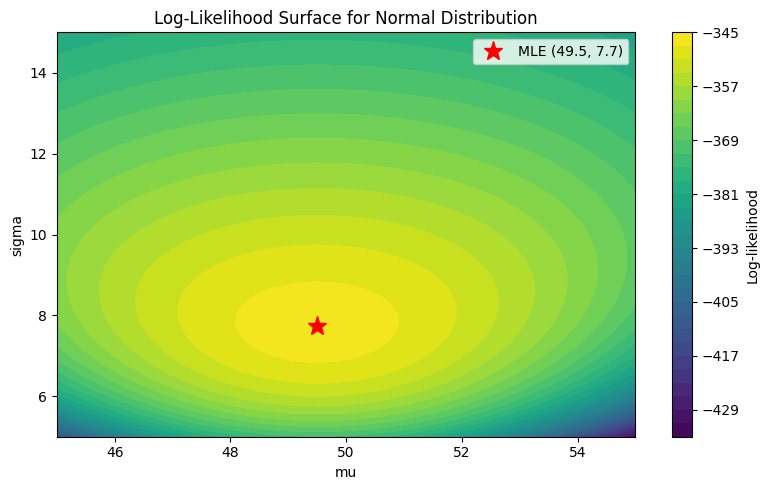

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, optimize

rng = np.random.default_rng(seed=42)

# True parameters
true_mu, true_sigma = 50, 10
data = rng.normal(true_mu, true_sigma, size=100)

# Analytical MLE
mu_mle    = data.mean()
sigma_mle = data.std(ddof=0)   # divide by n (MLE)
sigma_unb = data.std(ddof=1)   # divide by n-1 (unbiased)

print('MLE for Normal Distribution')
print(f'  True mu     : {true_mu}')
print(f'  MLE mu      : {mu_mle:.4f}  (same as sample mean)')
print(f'  True sigma  : {true_sigma}')
print(f'  MLE sigma   : {sigma_mle:.4f}  (divides by n — biased)')
print(f'  Unbiased s  : {sigma_unb:.4f}  (divides by n-1)')
print()

# Log-likelihood surface
mus    = np.linspace(45, 55, 200)
sigmas = np.linspace(5,  15, 200)
MU, SIG = np.meshgrid(mus, sigmas)

# Vectorised log-likelihood
ll = np.array([
    np.sum(stats.norm.logpdf(data, loc=m, scale=s))
    for m, s in zip(MU.ravel(), SIG.ravel())
]).reshape(MU.shape)

fig, ax = plt.subplots(figsize=(8, 5))
cp = ax.contourf(MU, SIG, ll, levels=30, cmap='viridis')
plt.colorbar(cp, label='Log-likelihood')
ax.plot(mu_mle, sigma_mle, 'r*', ms=14, label=f'MLE ({mu_mle:.1f}, {sigma_mle:.1f})')
ax.set_xlabel('mu')
ax.set_ylabel('sigma')
ax.set_title('Log-Likelihood Surface for Normal Distribution')
ax.legend()
plt.tight_layout()
plt.show()


## MLE for the Exponential Distribution

For $X_i \sim \text{Exp}(\lambda)$, the log-likelihood is:
$$\ell(\lambda) = n\ln\lambda - \lambda \sum_{i=1}^n x_i$$

The MLE is:
$$\hat{\lambda}_{MLE} = \frac{n}{\sum x_i} = \frac{1}{\bar{x}}$$

MLE for Exponential Distribution
  True lambda (rate)  : 0.02
  True mean (1/lambda): 50.0
  MLE lambda          : 0.02039
  MLE mean (1/lambda) : 49.04



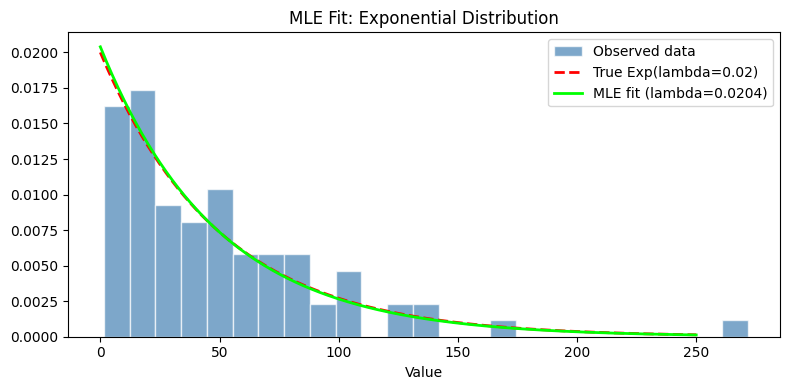

In [2]:
# Data from an exponential distribution
true_lam = 0.02   # mean = 1/0.02 = 50
exp_data  = rng.exponential(scale=1/true_lam, size=80)

lam_mle = 1 / exp_data.mean()

print('MLE for Exponential Distribution')
print(f'  True lambda (rate)  : {true_lam}')
print(f'  True mean (1/lambda): {1/true_lam:.1f}')
print(f'  MLE lambda          : {lam_mle:.5f}')
print(f'  MLE mean (1/lambda) : {1/lam_mle:.2f}')
print()

# Visualise fit
x = np.linspace(0, 250, 300)
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(exp_data, bins=25, density=True, color='steelblue', edgecolor='white', alpha=0.7, label='Observed data')
ax.plot(x, stats.expon.pdf(x, scale=1/true_lam), 'r--', lw=2, label=f'True Exp(lambda={true_lam})')
ax.plot(x, stats.expon.pdf(x, scale=1/lam_mle),  'lime', lw=2, label=f'MLE fit (lambda={lam_mle:.4f})')
ax.set_xlabel('Value')
ax.set_title('MLE Fit: Exponential Distribution')
ax.legend()
plt.tight_layout()
plt.show()


## Numerical MLE with scipy.optimize

For distributions without a closed-form solution, we minimise the **negative log-likelihood** numerically.

In [3]:
from scipy.optimize import minimize

# Fit a Gamma distribution to our exponential data (Gamma generalises Exponential)
# Gamma params: shape (k) and scale (theta), mean = k*theta

def neg_loglik_gamma(params):
    k, theta = params
    if k <= 0 or theta <= 0:
        return 1e10
    return -np.sum(stats.gamma.logpdf(exp_data, a=k, scale=theta))

result = minimize(neg_loglik_gamma, x0=[1.5, 40], method='Nelder-Mead')
k_mle, theta_mle = result.x

print('Numerical MLE — Gamma Distribution')
print(f'  MLE shape (k)    : {k_mle:.4f}  (expect ~1 since data is Exponential)')
print(f'  MLE scale (theta): {theta_mle:.4f}')
print(f'  MLE mean (k*theta): {k_mle*theta_mle:.2f}  (true mean = {1/true_lam:.1f})')
print(f'  Convergence: {result.success}')
print()
print('When k=1 the Gamma reduces to Exponential — MLE correctly identifies this.')


Numerical MLE — Gamma Distribution
  MLE shape (k)    : 1.3083  (expect ~1 since data is Exponential)
  MLE scale (theta): 37.4831
  MLE mean (k*theta): 49.04  (true mean = 50.0)
  Convergence: True

When k=1 the Gamma reduces to Exponential — MLE correctly identifies this.


---
## ML/AI Connection

- **Training a neural network** with cross-entropy loss is MLE of the model parameters under a Bernoulli/Categorical distribution on the labels — the loss function IS the negative log-likelihood.
- **Linear regression** fitted by minimising MSE is MLE under the assumption that residuals are normally distributed ($\varepsilon \sim \mathcal{N}(0,\sigma^2)$).
- **Logistic regression** maximises the Bernoulli log-likelihood via gradient ascent — equivalent to minimising binary cross-entropy.
- **Expectation-Maximisation (EM)** for Gaussian Mixture Models alternates between E-step (posterior) and M-step (MLE update).
